In [1]:
import random
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
raw_datasets = load_dataset("dair-ai/emotion")
class_names = raw_datasets["train"].features["label"].names
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}\n")

train_val = raw_datasets["train"].train_test_split(test_size=0.1, seed=SEED)
dataset_splits = DatasetDict({
    "train": train_val["train"],
    "validation": train_val["test"],
    "test": raw_datasets["test"]
})

print("Dataset splits sizes:")
for split, ds in dataset_splits.items():
    print(f"  {split}: {len(ds)} examples")

print("\nSample texts and labels:")
for i in range(4):
    text = dataset_splits["train"][i]["text"]
    label = dataset_splits["train"][i]["label"]
    print(f"[{class_names[label].upper():<8}] {text}")

print("\nTask: Multi-class text emotion classification (6 classes).")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6

Dataset splits sizes:
  train: 14400 examples
  validation: 1600 examples
  test: 2000 examples

Sample texts and labels:
[JOY     ] i first started and i m feeling more confident behind the wheel
[JOY     ] i feel so determined this time and i say this time because i have tried every diet under the sun
[ANGER   ] i feel that i annoy everyone much too much when im obnoxious and yeah
[JOY     ] i feel like she didnt seem to energetic or happy even her assistant was a bit off as she washed my hair after the dry cut she was pretty rough too like she wanted to quickly get it over with

Task: Multi-class text emotion classification (6 classes).


In [3]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

sample_texts = [
    "i feel so happy today",
    "why does this always happen to me? i'm so frustrated.",
    "i am really surprised by the results!"
]

with open("tokenization_examples.txt", "w", encoding="utf-8") as f:
    f.write("=== Tokenization Examples ===\n\n")
    for txt in sample_texts:
        enc = tokenizer(txt)
        tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])

        f.write(f"Text: {txt}\n")
        f.write(f"Tokens: {tokens}\n")
        f.write(f"Input IDs: {enc['input_ids']}\n")
        f.write(f"Attention Mask: {enc['attention_mask']}\n")
        f.write(f"Special tokens: [CLS] (id 101), [SEP] (id 102)\n")
        f.write("-" * 50 + "\n")

print("Tokenizer loaded. Examples saved to tokenization_examples.txt")
print("Padding/Truncation is applied dynamically via DataCollatorWithPadding during training.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded. Examples saved to tokenization_examples.txt
Padding/Truncation is applied dynamically via DataCollatorWithPadding during training.


In [6]:
print("Running inference with pre-trained baseline model...")

test_texts_baseline = [
    "i feel so happy today",
    "why does this always happen to me? i'm so frustrated.",
    "i am really surprised by the results!"
]

try:
    from transformers import pipeline
    sentiment_pipeline = pipeline(
        "text-classification",
        model="distilbert-base-uncased-finetuned-sst-2",
        framework="pt",
        device=0 if torch.cuda.is_available() else -1
    )

    for txt in test_texts_baseline:
        res = sentiment_pipeline(txt)[0]
        print(f"Text: {txt}")
        print(f"  Prediction: {res['label']} (confidence: {res['score']:.3f})\n")

except Exception as e:
    print(f"Warning: Could not load baseline model: {e}")
    print("Running simple heuristic baseline instead...\n")

    emotion_keywords = {
        "joy": ["happy", "glad", "great", "wonderful", "love", "excited"],
        "sadness": ["sad", "cry", "depressed", "lonely", "hurt", "loss"],
        "anger": ["angry", "mad", "hate", "frustrated", "annoyed"],
        "fear": ["scared", "afraid", "worried", "nervous", "anxious"],
        "surprise": ["surprised", "shocked", "unexpected", "wow"],
        "love": ["love", "adore", "cherish", "affection"]
    }

    for txt in test_texts_baseline:
        txt_lower = txt.lower()
        scores = {}
        for emotion, keywords in emotion_keywords.items():
            scores[emotion] = sum(1 for kw in keywords if kw in txt_lower)

        if max(scores.values()) > 0:
            pred = max(scores, key=scores.get)
            conf = scores[pred] / sum(scores.values())
        else:
            pred = "unknown"
            conf = 0.0

        print(f"Text: {txt}")
        print(f"  Heuristic prediction: {pred} (score: {conf:.2f})\n")

print("Conclusion: Pre-trained sentiment models use binary labels (Positive/Negative),")
print("while our task requires 6-way emotion classification. Fine-tuning is necessary.")

Running inference with pre-trained baseline model...
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Running simple heuristic baseline instead...

Text: i feel so happy today
  Heuristic prediction: joy (score: 1.00)

Text: why does this always happen to me? i'm so frustrated.
  Heuristic prediction: anger (score: 1.00)

Text: i am really surprised by the results!
  Heuristic prediction: surprise (score: 1.00)

Conclusion: Pre-trained sentiment models use binary labels (Positive/Negative),
while our task requires 6-way emotion classification. Fine-tuning is necessary.


In [7]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=False)

tokenized_datasets = dataset_splits.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)
print("Data tokenized and prepared.")

Map:   0%|          | 0/14400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Data tokenized and prepared.


In [11]:
num_labels = len(class_names)
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

import transformers
from packaging import version

if version.parse(transformers.__version__) >= version.parse("4.30.0"):
    processing_class_arg = {"processing_class": tokenizer}
else:
    processing_class_arg = {"tokenizer": tokenizer}

training_args = TrainingArguments(
    output_dir="./emotion_bert_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    **processing_class_arg
)

print("Starting training...")
trainer.train()
print("Training finished. Best validation model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.233133,0.191005,0.931250,0.898975
2,0.148336,0.156241,0.931875,0.899206
3,0.115566,0.147186,0.937500,0.906013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training finished. Best validation model loaded.


Final evaluation on test set...


Accuracy (Test): 0.9260
F1-Macro (Test): 0.8844


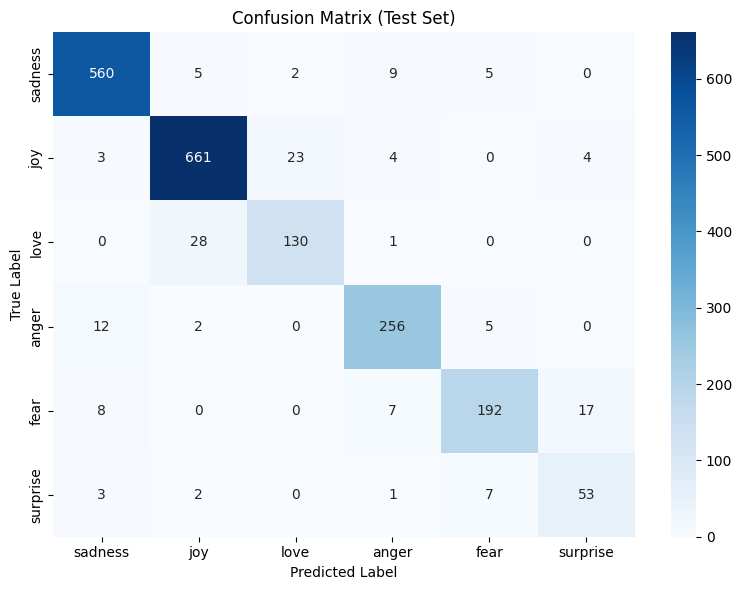


sample_predictions.csv saved.
                                                                                                           text true_label pred_label  confidence
                                  i feel unprotected a class post count link href http reprogramming in process    sadness       fear    0.988958
i decided to actually paint this piece in a common canvas because painting in canvas make me feel very artistic        joy        joy    0.998057
                                                         i spent the last two weeks of school feeling miserable    sadness    sadness    0.996754
                                          im polyamorous something im starting to feel truly accepted for being       love        joy    0.501236
                                                              i feel like damaged goods no one will want me now    sadness    sadness    0.996887
                    i feel like rich purple and gold are a match made in heaven and this rein

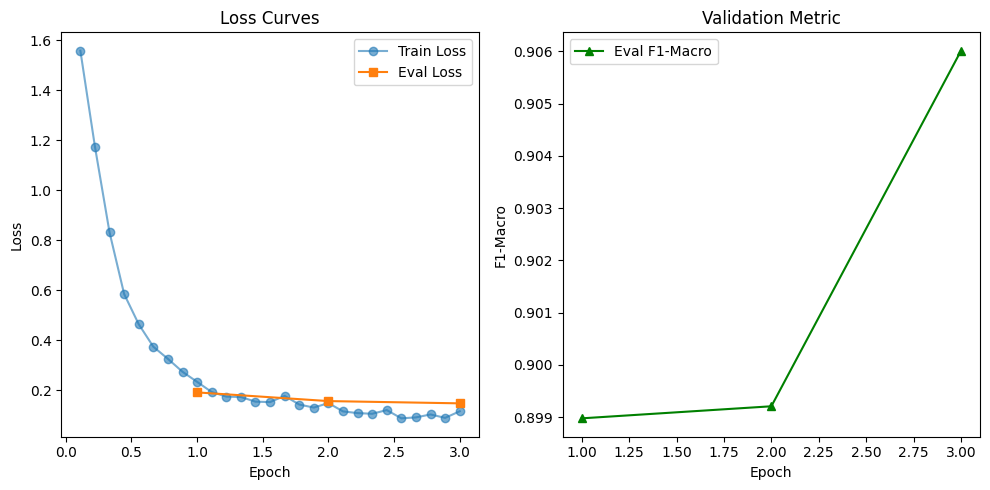

Artifacts saved: confusion_matrix.png, training_curves.png, sample_predictions.csv, tokenization_examples.txt


In [14]:
print("Final evaluation on test set...")
predictions = trainer.predict(tokenized_datasets["test"])
test_logits = predictions.predictions
test_labels = predictions.label_ids

test_preds = np.argmax(test_logits, axis=1)
test_confidence = np.max(softmax(test_logits, axis=1), axis=1)

acc = accuracy_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds, average="macro")
print(f"Accuracy (Test): {acc:.4f}")
print(f"F1-Macro (Test): {f1:.4f}")

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

sample_indices = np.random.choice(len(test_labels), size=8, replace=False)
df_samples = pd.DataFrame({
    "text": [dataset_splits["test"][int(i)]["text"] for i in sample_indices],
    "true_label": [class_names[int(test_labels[i])] for i in sample_indices],
    "pred_label": [class_names[int(test_preds[i])] for i in sample_indices],
    "confidence": [float(test_confidence[i]) for i in sample_indices]
})
df_samples.to_csv("sample_predictions.csv", index=False)
print("\nsample_predictions.csv saved.")
print(df_samples.to_string(index=False))

print("\nError analysis:")
mask_errors = test_labels != test_preds
error_indices = np.where(mask_errors)[0]
if len(error_indices) > 0:
    for idx in error_indices[:5]:
        idx_int = int(idx)
        true = class_names[int(test_labels[idx_int])]
        pred = class_names[int(test_preds[idx_int])]
        conf = float(test_confidence[idx_int])
        txt = dataset_splits["test"][idx_int]["text"]
        print(f"[{true.upper()} -> {pred.upper()}] (conf={conf:.2f}) | {txt}")
    print("\nComment: Errors typically occur on texts with sarcasm, mixed emotional signals, or lexically similar classes (e.g., fear vs surprise).")
else:
    print("No errors in the sampled batch.")

log_history = trainer.state.log_history

# Валидационные логи
eval_logs = [log for log in log_history if "eval_f1_macro" in log]
epochs = [log["epoch"] for log in eval_logs]
eval_loss = [log["eval_loss"] for log in eval_logs]
eval_f1 = [log["eval_f1_macro"] for log in eval_logs]

# Обучающие логи
train_logs = [log for log in log_history if "loss" in log and "eval_loss" not in log]
train_epochs = [log["epoch"] for log in train_logs]
train_loss = [log["loss"] for log in train_logs]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
if train_epochs:
    plt.plot(train_epochs, train_loss, label="Train Loss", marker="o", alpha=0.6)
plt.plot(epochs, eval_loss, label="Eval Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(epochs, eval_f1, label="Eval F1-Macro", color="green", marker="^")
plt.xlabel("Epoch")
plt.ylabel("F1-Macro")
plt.legend()
plt.title("Validation Metric")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("Artifacts saved: confusion_matrix.png, training_curves.png, sample_predictions.csv, tokenization_examples.txt")